In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load dataset
df = pd.read_csv("../data/raw/updated_pollution_dataset.csv")

# Encode target column
label_encoder = LabelEncoder()
df["Air Quality"] = label_encoder.fit_transform(df["Air Quality"])

print("Classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

# Separate input and output
X = df.drop("Air Quality", axis=1)
y = df["Air Quality"]

Classes:
0 = Good
1 = Hazardous
2 = Moderate
3 = Poor


In [3]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (4000, 9)
X_test: (1000, 9)


In [4]:
# Scale features
# Important: fit scaler only on training data, then transform both train and test data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Train Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
# Test model
y_pred_lr = logistic_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.929

Classification Report:
              precision    recall  f1-score   support

        Good       0.99      1.00      0.99       400
   Hazardous       0.90      0.77      0.83       100
    Moderate       0.93      0.94      0.94       300
        Poor       0.82      0.85      0.84       200

    accuracy                           0.93      1000
   macro avg       0.91      0.89      0.90      1000
weighted avg       0.93      0.93      0.93      1000



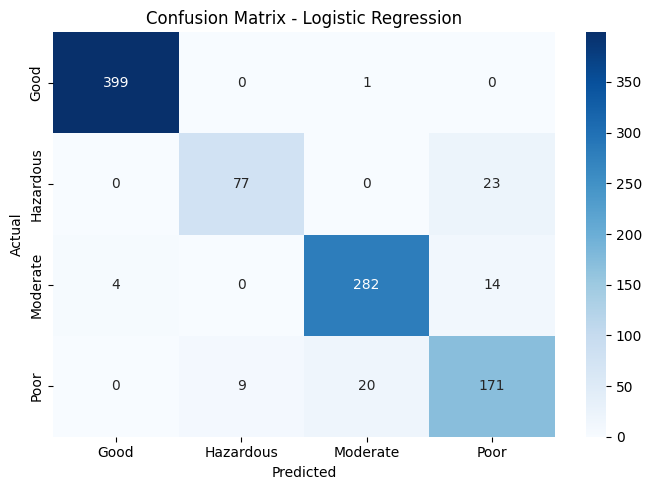

In [7]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/plots/logistic_regression_confusion_matrix.png", dpi=300)
plt.show()

In [8]:
# Save model and scaler
joblib.dump(logistic_model, "../outputs/models/logistic_regression.pkl")
joblib.dump(scaler, "../outputs/models/scaler.pkl")
joblib.dump(label_encoder, "../outputs/models/label_encoder.pkl")

['../outputs/models/label_encoder.pkl']

In [46]:
#saving logistic regression results 
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Save accuracy in a dataframe
metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_lr]
})

metrics_df.to_csv("../outputs/plots/logistic_regression_accuracy.csv", index=False)

# Save classification report
report_dict = classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("../outputs/plots/logistic_regression_classification_report.csv")

In [47]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

In [48]:
# Train Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [49]:
# Test Decision Tree model
y_pred_dt = decision_tree_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

Decision Tree Accuracy: 0.902

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      0.98      0.99       400
   Hazardous       0.83      0.72      0.77       100
    Moderate       0.89      0.93      0.91       300
        Poor       0.77      0.80      0.78       200

    accuracy                           0.90      1000
   macro avg       0.87      0.86      0.86      1000
weighted avg       0.90      0.90      0.90      1000



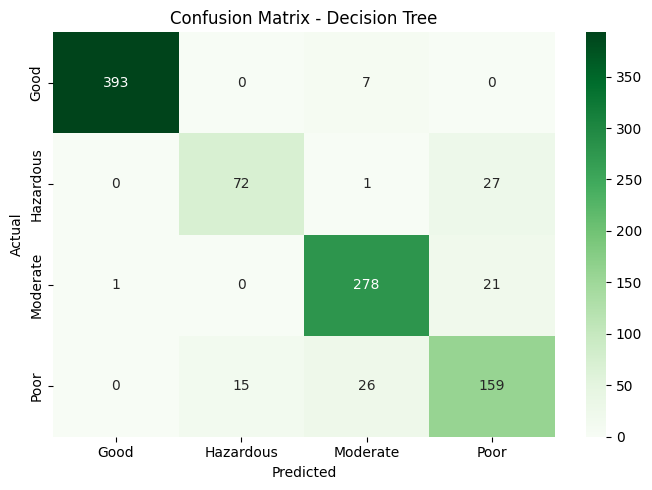

In [50]:
cm_dt = confusion_matrix(y_test, y_pred_dt)# confusion matrix

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/plots/decision_tree_confusion_matrix.png", dpi=300)
plt.show()

In [51]:
# Save accuracy
metrics_dt_df = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [accuracy_dt]
})

metrics_dt_df.to_csv("../outputs/plots/decision_tree_accuracy.csv", index=False)

# Save classification report
report_dt_dict = classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_dt_df = pd.DataFrame(report_dt_dict).transpose()
report_dt_df.to_csv("../outputs/plots/decision_tree_classification_report.csv")

# Save text result
with open("../outputs/plots/decision_tree_results.txt", "w") as f:
    f.write(f"Accuracy: {accuracy_dt}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

# Save model
joblib.dump(decision_tree_model, "../outputs/models/decision_tree.pkl")

['../outputs/models/decision_tree.pkl']

In [52]:
#MLP
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import joblib

In [53]:
# Convert data to PyTorch tensors

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [54]:
# Create DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [55]:
# Define MLP model

class MLPClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLPClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [56]:
# Model setup

input_size = X_train_scaled.shape[1]   # 9 features
num_classes = len(label_encoder.classes_)   # 4 classes

mlp_model = MLPClassifier(input_size, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [57]:
# Train MLP model

epochs = 40
train_losses = []

for epoch in range(epochs):
    mlp_model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Forward pass
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/40], Loss: 0.6137
Epoch [2/40], Loss: 0.2687
Epoch [3/40], Loss: 0.2249
Epoch [4/40], Loss: 0.2014
Epoch [5/40], Loss: 0.1908
Epoch [6/40], Loss: 0.1799
Epoch [7/40], Loss: 0.1737
Epoch [8/40], Loss: 0.1691
Epoch [9/40], Loss: 0.1591
Epoch [10/40], Loss: 0.1605
Epoch [11/40], Loss: 0.1557
Epoch [12/40], Loss: 0.1531
Epoch [13/40], Loss: 0.1516
Epoch [14/40], Loss: 0.1482
Epoch [15/40], Loss: 0.1420
Epoch [16/40], Loss: 0.1479
Epoch [17/40], Loss: 0.1409
Epoch [18/40], Loss: 0.1386
Epoch [19/40], Loss: 0.1368
Epoch [20/40], Loss: 0.1400
Epoch [21/40], Loss: 0.1349
Epoch [22/40], Loss: 0.1296
Epoch [23/40], Loss: 0.1287
Epoch [24/40], Loss: 0.1301
Epoch [25/40], Loss: 0.1271
Epoch [26/40], Loss: 0.1222
Epoch [27/40], Loss: 0.1303
Epoch [28/40], Loss: 0.1259
Epoch [29/40], Loss: 0.1287
Epoch [30/40], Loss: 0.1193
Epoch [31/40], Loss: 0.1219
Epoch [32/40], Loss: 0.1150
Epoch [33/40], Loss: 0.1159
Epoch [34/40], Loss: 0.1194
Epoch [35/40], Loss: 0.1115
Epoch [36/40], Loss: 0.1154
E

In [58]:
# Evaluate model

mlp_model.eval()

with torch.no_grad():
    test_outputs = mlp_model(X_test_tensor)
    _, y_pred_mlp_tensor = torch.max(test_outputs, 1)

y_pred_mlp = y_pred_mlp_tensor.numpy()

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

print("MLP Neural Network Accuracy:", accuracy_mlp)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))

MLP Neural Network Accuracy: 0.944

Classification Report:
              precision    recall  f1-score   support

        Good       0.99      1.00      0.99       400
   Hazardous       0.87      0.83      0.85       100
    Moderate       0.96      0.95      0.95       300
        Poor       0.88      0.88      0.88       200

    accuracy                           0.94      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.94      0.94      0.94      1000



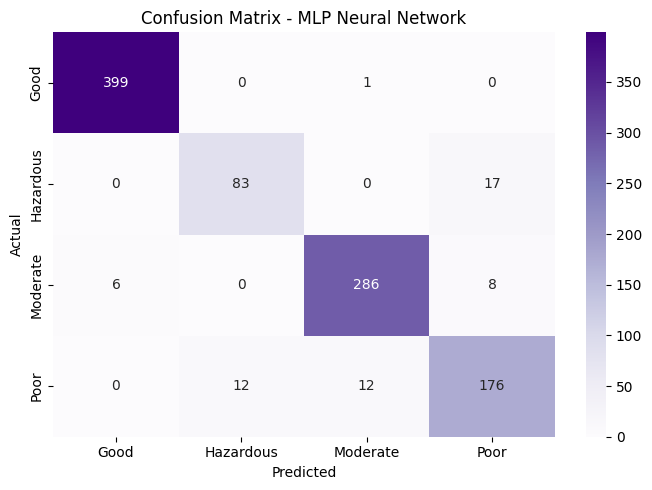

In [59]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - MLP Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/plots/mlp_confusion_matrix.png", dpi=300)
plt.show()

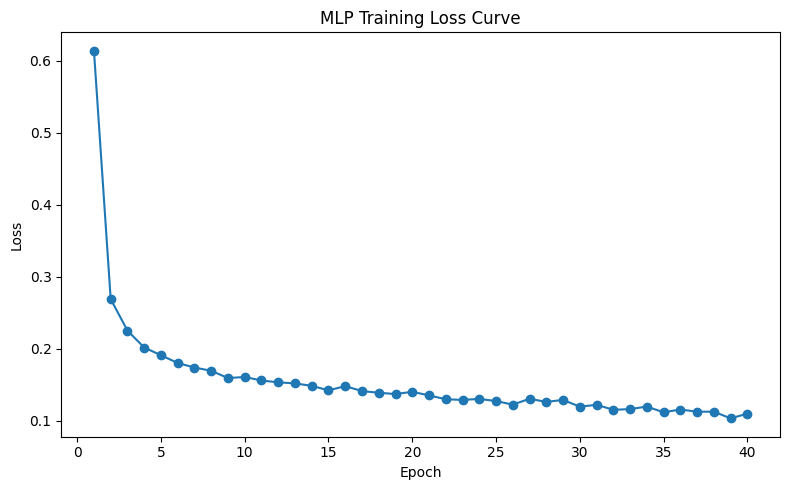

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.title("MLP Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("../outputs/plots/mlp_training_loss_curve.png", dpi=300)
plt.show()

In [61]:
# Save accuracy
metrics_mlp_df = pd.DataFrame({
    "Model": ["MLP Neural Network"],
    "Accuracy": [accuracy_mlp]
})

metrics_mlp_df.to_csv("../outputs/plots/mlp_accuracy.csv", index=False)

# Save classification report
report_mlp_dict = classification_report(
    y_test,
    y_pred_mlp,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_mlp_df = pd.DataFrame(report_mlp_dict).transpose()
report_mlp_df.to_csv("../outputs/plots/mlp_classification_report.csv")

# Save text result
with open("../outputs/plots/mlp_results.txt", "w") as f:
    f.write(f"Accuracy: {accuracy_mlp}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))

# Save model
torch.save(mlp_model.state_dict(), "../outputs/models/mlp_neural_network.pth")

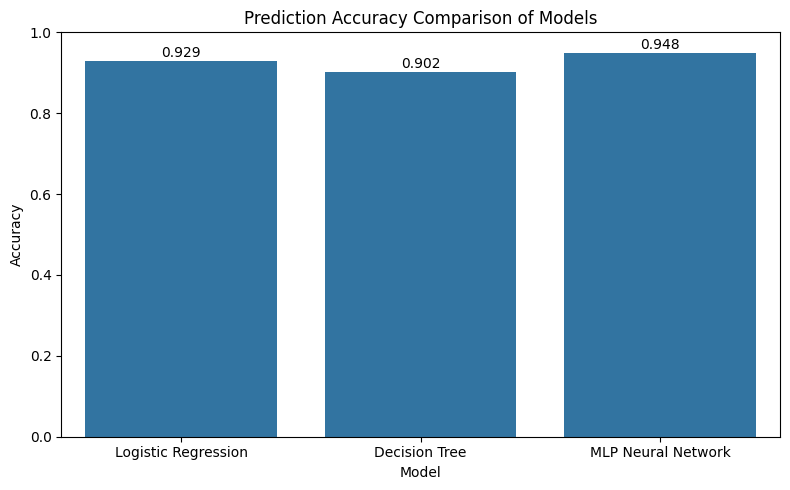

In [62]:
#accuracy prediction barchart
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Replace these values with your actual results
accuracy_lr = 0.929
accuracy_dt = 0.902
accuracy_mlp = 0.948

accuracy_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "MLP Neural Network"],
    "Accuracy": [accuracy_lr, accuracy_dt, accuracy_mlp]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=accuracy_df, x="Model", y="Accuracy")

plt.title("Prediction Accuracy Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for index, value in enumerate(accuracy_df["Accuracy"]):
    plt.text(index, value + 0.01, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.savefig("../outputs/plots/model_accuracy_comparison.png", dpi=300)
plt.show()

                 Model  Precision    Recall
0  Logistic Regression   0.909558  0.890625
1        Decision Tree   0.871047  0.856042
2   MLP Neural Network   0.922753  0.915208


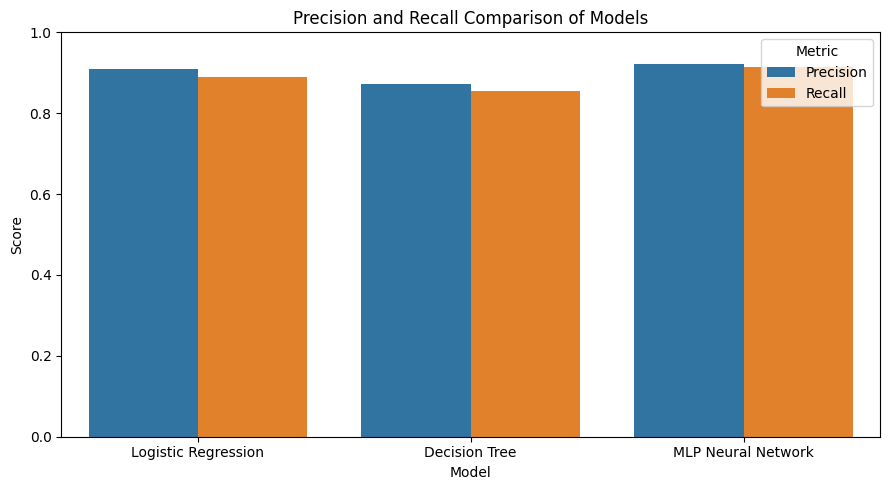

In [63]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate macro precision and recall for each model
precision_lr = precision_score(y_test, y_pred_lr, average="macro")
recall_lr = recall_score(y_test, y_pred_lr, average="macro")

precision_dt = precision_score(y_test, y_pred_dt, average="macro")
recall_dt = recall_score(y_test, y_pred_dt, average="macro")

precision_mlp = precision_score(y_test, y_pred_mlp, average="macro")
recall_mlp = recall_score(y_test, y_pred_mlp, average="macro")

# Create comparison dataframe
precision_recall_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "MLP Neural Network"
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_mlp
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_mlp
    ]
})

print(precision_recall_df)

# Convert to long format for bar chart
precision_recall_long = precision_recall_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall"],
    var_name="Metric",
    value_name="Score"
)

# Plot comparison bar chart
plt.figure(figsize=(9, 5))
sns.barplot(
    data=precision_recall_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Precision and Recall Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("../outputs/plots/precision_recall_comparison.png", dpi=300)
plt.show()

# Save values as CSV
precision_recall_df.to_csv("../outputs/plots/precision_recall_comparison.csv", index=False)

In [64]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [65]:
# Number of classes
num_classes = len(label_encoder.classes_)

# Binarize y_test for multi-class ROC
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

# Logistic Regression probabilities
y_score_lr = logistic_model.predict_proba(X_test_scaled)

# Decision Tree probabilities
y_score_dt = decision_tree_model.predict_proba(X_test)

# MLP probabilities
mlp_model.eval()
with torch.no_grad():
    mlp_outputs = mlp_model(X_test_tensor)
    y_score_mlp = torch.softmax(mlp_outputs, dim=1).numpy()

In [66]:
auc_lr = roc_auc_score(y_test_bin, y_score_lr, average="macro", multi_class="ovr")
auc_dt = roc_auc_score(y_test_bin, y_score_dt, average="macro", multi_class="ovr")
auc_mlp = roc_auc_score(y_test_bin, y_score_mlp, average="macro", multi_class="ovr")

auc_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "MLP Neural Network"],
    "AUC Score": [auc_lr, auc_dt, auc_mlp]
})

print(auc_df)

auc_df.to_csv("../outputs/plots/auc_scores.csv", index=False)

                 Model  AUC Score
0  Logistic Regression   0.991177
1        Decision Tree   0.972113
2   MLP Neural Network   0.993769


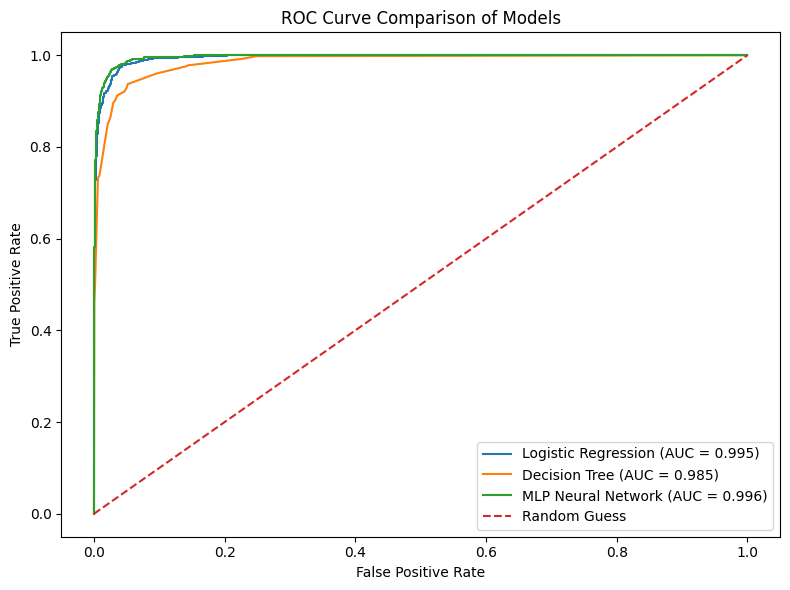

In [67]:
models_scores = {
    "Logistic Regression": y_score_lr,
    "Decision Tree": y_score_dt,
    "MLP Neural Network": y_score_mlp
}

plt.figure(figsize=(8, 6))

for model_name, y_score in models_scores.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison of Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/roc_curve_comparison.png", dpi=300)
plt.show()

In [68]:
# K means clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [69]:
# For unsupervised learning, not use the target column
X_cluster = df.drop("Air Quality", axis=1)
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

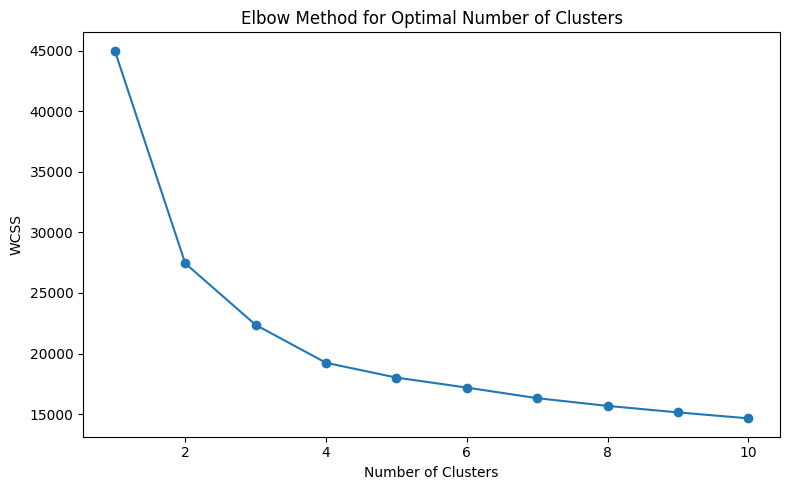

In [70]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig("../outputs/plots/kmeans_elbow_method.png", dpi=300)
plt.show()

In [71]:
#Applying Kmeans . As data set has 4 classes for Output air quality, n_clusters = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality,Cluster
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,2,1
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,2,1
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,2,1
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,0,3
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,0,3


In [72]:
cluster_quality_table = pd.crosstab(df["Cluster"], df["Air Quality"])
print(cluster_quality_table)

cluster_quality_table.to_csv("../outputs/plots/kmeans_cluster_vs_air_quality.csv")

Air Quality     0    1     2    3
Cluster                          
0               0  366     5  539
1               2    3  1361  290
2               1  131    64  170
3            1997    0    70    1
